In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


import tensorflow as tf
from tensorflow.keras.layers import Dense,BatchNormalization,Conv2D,Flatten,Dropout,MaxPooling2D,GlobalMaxPooling2D
from tensorflow.keras.models import Sequential
from  tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
! kaggle datasets download -d ashery/chexpert

Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [08:44<00:00, 21.9MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('/content/chexpert.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done")

Done


In [4]:
train_df=pd.read_csv('/content/dataset/train.csv')
train_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [5]:
valid_df=pd.read_csv('/content/dataset/valid.csv')
valid_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/valid/patient64541/study1/...,Male,73,Frontal,AP,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Frontal,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Lateral,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CheXpert-v1.0-small/valid/patient64543/study1/...,Male,85,Frontal,AP,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64544/study1/...,Female,42,Frontal,AP,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_df.shape

(223414, 19)

In [7]:



original_train_sample = train_df.sample(n=5000, random_state=42)



original_train_sample.to_csv('train_subset_2000.csv', index=False)

print(f"rows: {len(original_train_sample)}")
print(original_train_sample.isnull().sum())

rows: 5000
Path                             0
Sex                              0
Age                              0
Frontal/Lateral                  0
AP/PA                          719
No Finding                    4505
Enlarged Cardiomediastinum    3970
Cardiomegaly                  3986
Lung Opacity                  2348
Lung Lesion                   4733
Edema                         3072
Consolidation                 3459
Pneumonia                     4395
Atelectasis                   3496
Pneumothorax                  3225
Pleural Effusion              2042
Pleural Other                 4841
Fracture                      4702
Support Devices               2291
dtype: int64


In [8]:
disease_cols = original_train_sample.columns[-14:]
disease_cols

Index(['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
       'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
       'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other',
       'Fracture', 'Support Devices'],
      dtype='object')

In [9]:

for col in disease_cols:
  print(f"{col}: {original_train_sample[col].unique()}")

No Finding: [ 1. nan]
Enlarged Cardiomediastinum: [ 0. nan  1. -1.]
Cardiomegaly: [nan  1.  0. -1.]
Lung Opacity: [nan  1. -1.  0.]
Lung Lesion: [nan  1. -1.  0.]
Edema: [nan  1. -1.  0.]
Consolidation: [nan -1.  0.  1.]
Pneumonia: [nan -1.  1.  0.]
Atelectasis: [nan  1. -1.  0.]
Pneumothorax: [ 0. nan -1.  1.]
Pleural Effusion: [ 0. nan  1. -1.]
Pleural Other: [nan  1. -1.  0.]
Fracture: [nan  1.  0. -1.]
Support Devices: [nan  1.  0. -1.]


In [10]:
def process(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(0)
    df[cols] = df[cols].replace(-1, 0)
    return df

In [11]:
train_sample=process(original_train_sample,disease_cols)

In [12]:
#After Process
for col in disease_cols:
  print(col)
  print(f" {train_sample[col].unique()}")
  print(f"{train_sample[col].value_counts()}")

No Finding
 [1. 0.]
No Finding
0.0    4505
1.0     495
Name: count, dtype: int64
Enlarged Cardiomediastinum
 [0. 1.]
Enlarged Cardiomediastinum
0.0    4765
1.0     235
Name: count, dtype: int64
Cardiomegaly
 [0. 1.]
Cardiomegaly
0.0    4413
1.0     587
Name: count, dtype: int64
Lung Opacity
 [0. 1.]
Lung Opacity
0.0    2641
1.0    2359
Name: count, dtype: int64
Lung Lesion
 [0. 1.]
Lung Lesion
0.0    4796
1.0     204
Name: count, dtype: int64
Edema
 [0. 1.]
Edema
0.0    3867
1.0    1133
Name: count, dtype: int64
Consolidation
 [0. 1.]
Consolidation
0.0    4680
1.0     320
Name: count, dtype: int64
Pneumonia
 [0. 1.]
Pneumonia
0.0    4854
1.0     146
Name: count, dtype: int64
Atelectasis
 [0. 1.]
Atelectasis
0.0    4249
1.0     751
Name: count, dtype: int64
Pneumothorax
 [0. 1.]
Pneumothorax
0.0    4565
1.0     435
Name: count, dtype: int64
Pleural Effusion
 [0. 1.]
Pleural Effusion
0.0    3111
1.0    1889
Name: count, dtype: int64
Pleural Other
 [0. 1.]
Pleural Other
0.0    4911
1.0   

In [13]:
train_sample.columns

Index(['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding',
       'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices'],
      dtype='object')

In [14]:
train_sample=train_sample.drop(['Sex', 'Age', 'Frontal/Lateral', 'AP/PA'],axis=1)


In [15]:
train_sample

,Path,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
305,CheXpert-v1.0-small/train/patient00082/study1/...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
151324,CheXpert-v1.0-small/train/patient35759/study9/...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
19284,CheXpert-v1.0-small/train/patient04789/study1/...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
165026,CheXpert-v1.0-small/train/patient38491/study5/...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
26786,CheXpert-v1.0-small/train/patient06537/study3/...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29989,CheXpert-v1.0-small/train/patient07291/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99698,CheXpert-v1.0-small/train/patient24001/study2/...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
35456,CheXpert-v1.0-small/train/patient08694/study1/...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221713,CheXpert-v1.0-small/train/patient63002/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
valid_df.isnull().sum()

,0
Path,0
Sex,0
Age,0
Frontal/Lateral,0
AP/PA,32
No Finding,0
Enlarged Cardiomediastinum,0
Cardiomegaly,0
Lung Opacity,0
Lung Lesion,0


In [17]:
for col in disease_cols:
  print(f"{col}: {valid_df[col].unique()}")

No Finding: [0. 1.]
Enlarged Cardiomediastinum: [1. 0.]
Cardiomegaly: [1. 0.]
Lung Opacity: [1. 0.]
Lung Lesion: [0. 1.]
Edema: [0. 1.]
Consolidation: [0. 1.]
Pneumonia: [0. 1.]
Atelectasis: [0. 1.]
Pneumothorax: [0. 1.]
Pleural Effusion: [0. 1.]
Pleural Other: [0. 1.]
Fracture: [0.]
Support Devices: [0. 1.]


In [18]:
valid_df=valid_df.drop(['Sex', 'Age', 'Frontal/Lateral', 'AP/PA'],axis=1)

In [19]:
valid_df

,Path,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,CheXpert-v1.0-small/valid/patient64542/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CheXpert-v1.0-small/valid/patient64543/study1/...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64544/study1/...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,CheXpert-v1.0-small/valid/patient64736/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
230,CheXpert-v1.0-small/valid/patient64737/study1/...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
231,CheXpert-v1.0-small/valid/patient64738/study1/...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
232,CheXpert-v1.0-small/valid/patient64739/study1/...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
original_train_sample['Path']

,Path
305,CheXpert-v1.0-small/train/patient00082/study1/...
151324,CheXpert-v1.0-small/train/patient35759/study9/...
19284,CheXpert-v1.0-small/train/patient04789/study1/...
165026,CheXpert-v1.0-small/train/patient38491/study5/...
26786,CheXpert-v1.0-small/train/patient06537/study3/...
...,...
29989,CheXpert-v1.0-small/train/patient07291/study1/...
99698,CheXpert-v1.0-small/train/patient24001/study2/...
35456,CheXpert-v1.0-small/train/patient08694/study1/...
221713,CheXpert-v1.0-small/train/patient63002/study1/...


In [21]:
train_sample['Path']

,Path
305,CheXpert-v1.0-small/train/patient00082/study1/...
151324,CheXpert-v1.0-small/train/patient35759/study9/...
19284,CheXpert-v1.0-small/train/patient04789/study1/...
165026,CheXpert-v1.0-small/train/patient38491/study5/...
26786,CheXpert-v1.0-small/train/patient06537/study3/...
...,...
29989,CheXpert-v1.0-small/train/patient07291/study1/...
99698,CheXpert-v1.0-small/train/patient24001/study2/...
35456,CheXpert-v1.0-small/train/patient08694/study1/...
221713,CheXpert-v1.0-small/train/patient63002/study1/...


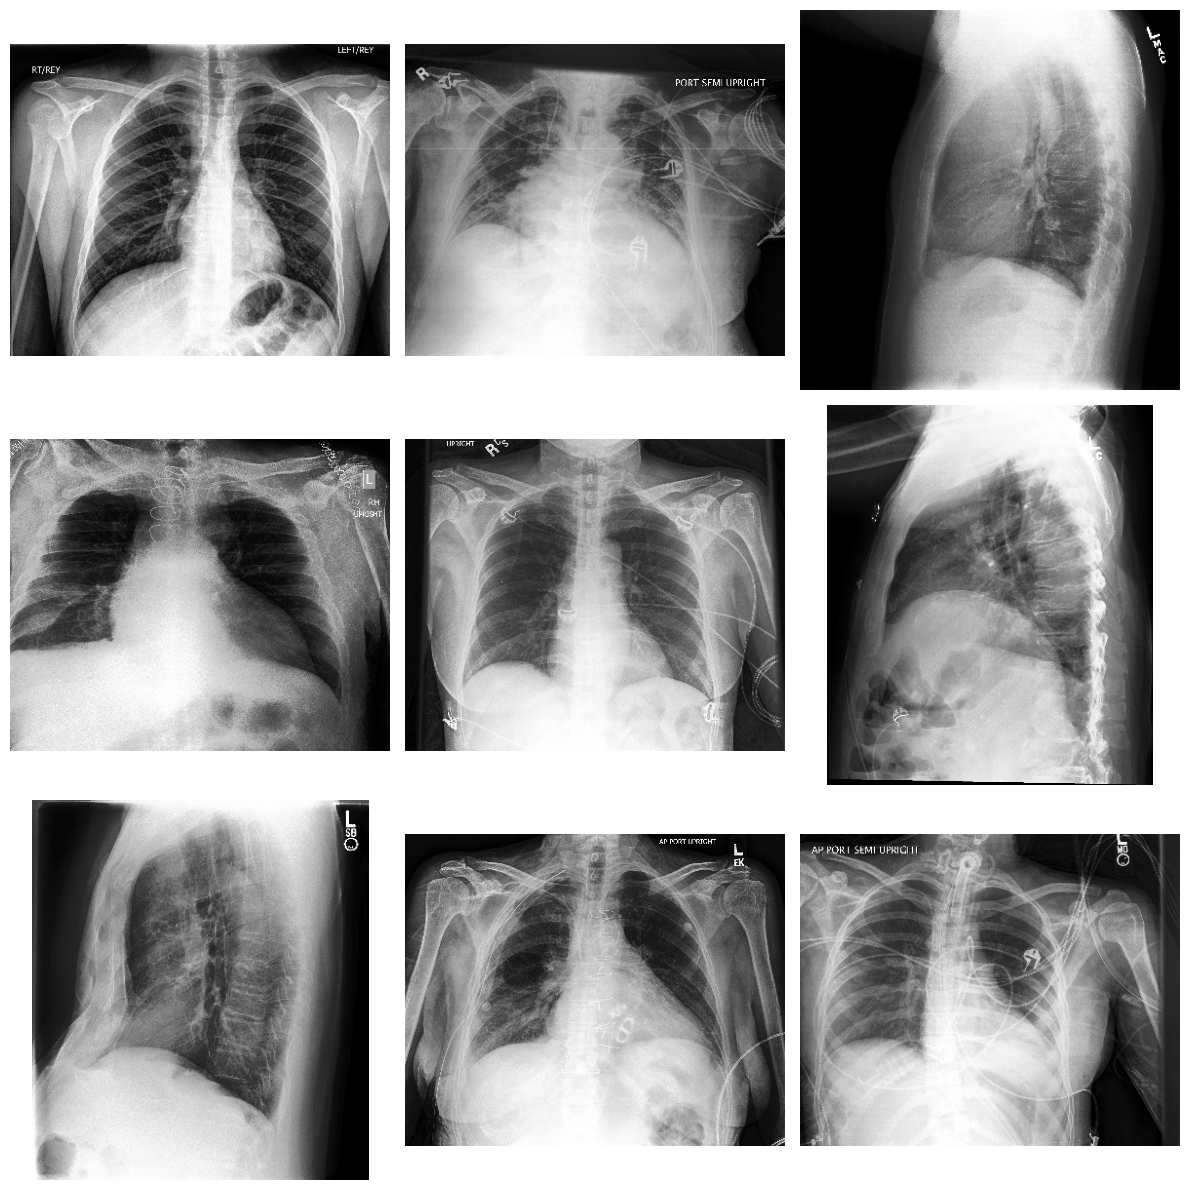

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

# Ensure train_sample['Path'] uses the original relative paths from original_train_sample
# before prepending, to prevent double-prefixing if the cell is run multiple times.
train_sample['Path'] = original_train_sample['Path'].copy()

# Prepend the correct directory to the image paths, assuming an extra 'chexpert' folder
# was created during extraction.
train_sample["Path"] = train_sample["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

train_sample['Path'] = '/content/dataset/' + train_sample['Path']

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    img = Image.open(train_sample["Path"].iloc[i])

    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

In [24]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_sample,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test_df = valid_df.copy()

In [25]:
tr_gen=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
     height_shift_range=0.1,
     zoom_range=0.2,
     horizontal_flip=True
)
ts_gen=ImageDataGenerator(preprocessing_function=preprocess_input)

In [26]:
print(train_df["Path"].head())
print(val_df["Path"].head())
print(test_df["Path"].head())

12173     /content/dataset/train/patient03032/study3/vie...
160745    /content/dataset/train/patient37570/study7/vie...
167672    /content/dataset/train/patient39118/study2/vie...
198318    /content/dataset/train/patient48842/study4/vie...
58392     /content/dataset/train/patient14142/study1/vie...
Name: Path, dtype: object
74214     /content/dataset/train/patient17802/study2/vie...
166175    /content/dataset/train/patient38754/study8/vie...
38053     /content/dataset/train/patient09331/study1/vie...
222729    /content/dataset/train/patient63923/study1/vie...
210082    /content/dataset/train/patient55153/study2/vie...
Name: Path, dtype: object
0    CheXpert-v1.0-small/valid/patient64541/study1/...
1    CheXpert-v1.0-small/valid/patient64542/study1/...
2    CheXpert-v1.0-small/valid/patient64542/study1/...
3    CheXpert-v1.0-small/valid/patient64543/study1/...
4    CheXpert-v1.0-small/valid/patient64544/study1/...
Name: Path, dtype: object


In [27]:
test_df["Path"] = test_df["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

test_df['Path'] = '/content/dataset/' + test_df['Path']

In [28]:
print(train_df["Path"].head())
print(valid_df["Path"].head())
print(test_df["Path"].head())

12173     /content/dataset/train/patient03032/study3/vie...
160745    /content/dataset/train/patient37570/study7/vie...
167672    /content/dataset/train/patient39118/study2/vie...
198318    /content/dataset/train/patient48842/study4/vie...
58392     /content/dataset/train/patient14142/study1/vie...
Name: Path, dtype: object
0    CheXpert-v1.0-small/valid/patient64541/study1/...
1    CheXpert-v1.0-small/valid/patient64542/study1/...
2    CheXpert-v1.0-small/valid/patient64542/study1/...
3    CheXpert-v1.0-small/valid/patient64543/study1/...
4    CheXpert-v1.0-small/valid/patient64544/study1/...
Name: Path, dtype: object
0    /content/dataset/valid/patient64541/study1/vie...
1    /content/dataset/valid/patient64542/study1/vie...
2    /content/dataset/valid/patient64542/study1/vie...
3    /content/dataset/valid/patient64543/study1/vie...
4    /content/dataset/valid/patient64544/study1/vie...
Name: Path, dtype: object


In [29]:
train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col='Path',
    y_col=disease_cols,
    target_size=(224,224),
    batch_size=16,
    class_mode='raw',
    shuffle=True
)

valid_gen = ts_gen.flow_from_dataframe(
    val_df,
    x_col='Path',
    y_col=disease_cols,
    target_size=(224,224),
    batch_size=16,
    class_mode='raw',
    shuffle=False
)

test_gen = ts_gen.flow_from_dataframe(
    test_df,
    x_col='Path',
    y_col=disease_cols,
    target_size=(224,224),
    batch_size=16,
    class_mode='raw',
    shuffle=False
)

Found 4000 validated image filenames.
Found 1000 validated image filenames.
Found 234 validated image filenames.


In [30]:
#build model
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='max'
)

base_model.trainable = False

model = Sequential([
    base_model,
    Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    BatchNormalization(),
    Dropout(0.4),
    Dense(14, activation='sigmoid')
])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,526 (27.86 MB)

 Trainable params: 266,510 (1.02 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [32]:
model.compile(
    optimizer=Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau,CSVLogger

In [34]:
call_backs=[
    EarlyStopping(patience=8,monitor='val_loss',restore_best_weights=True),
    ReduceLROnPlateau(patience=3,monitor='val_loss',factor=0.3,min_lr=1e-5),
    ModelCheckpoint('best_model.keras',monitor='val_loss',save_best_only=True),
    CSVLogger("training_log.csv")
]

In [35]:
history=model.fit(train_gen,validation_data=valid_gen,epochs=50,callbacks=call_backs)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 378ms/step - auc: 0.5398 - binary_accuracy: 0.5295 - loss: 0.8823 - val_auc: 0.6314 - val_binary_accuracy: 0.5824 - val_loss: 0.7520 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 253ms/step - auc: 0.5919 - binary_accuracy: 0.5880 - loss: 0.7582 - val_auc: 0.6524 - val_binary_accuracy: 0.6853 - val_loss: 0.6284 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 241ms/step - auc: 0.6295 - binary_accuracy: 0.6638 - loss: 0.6565 - val_auc: 0.5052 - val_binary_accuracy: 0.3194 - val_loss: 1.7093 - learning_rate: 1.0000e-04
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 245ms/step - auc: 0.6756 - binary_accuracy: 0.7461 - loss: 0.5577 - val_auc: 0.7332 - val_binary_accuracy: 0.8231 - val_loss: 0.4868 - learning_rate: 1.0000e-04
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - auc: 0.7183 - binary_accuracy: 0.8082 - loss: 0.4805 - val_auc: 0.7821 - val_binary_accuracy: 0.8464 - val_loss: 0.4175 - 

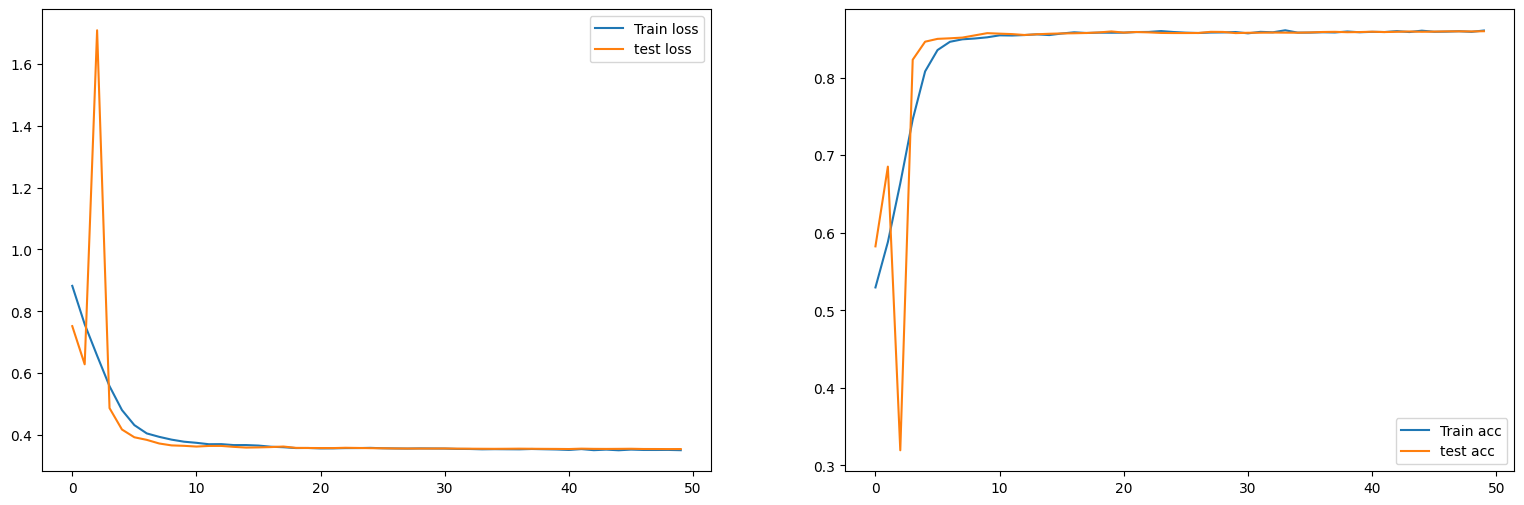

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(19,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='test loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['binary_accuracy'],label='Train acc')
plt.plot(history.history['val_binary_accuracy'],label='test acc')
plt.legend()

In [37]:
base_model.trainable=True

for layer in base_model.layers[:-10]:
  layer.trainable=False

In [38]:
model.compile(
    optimizer=Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [39]:
call_backs=[
    EarlyStopping(patience=8,monitor='val_loss',restore_best_weights=True),
    ReduceLROnPlateau(patience=3,monitor='val_loss',factor=0.3,min_lr=1e-5),
    ModelCheckpoint('best_model.keras',monitor='val_loss',save_best_only=True),
    CSVLogger("training_log.csv")
]

In [40]:
history=model.fit(train_gen,validation_data=valid_gen,epochs=10,callbacks=call_backs)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 332ms/step - auc: 0.8326 - binary_accuracy: 0.8586 - loss: 0.3529 - val_auc: 0.8253 - val_binary_accuracy: 0.8561 - val_loss: 0.3652 - learning_rate: 1.0000e-05
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 240ms/step - auc: 0.8340 - binary_accuracy: 0.8596 - loss: 0.3512 - val_auc: 0.8228 - val_binary_accuracy: 0.8544 - val_loss: 0.3699 - learning_rate: 1.0000e-05
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 61s 246ms/step - auc: 0.8348 - binary_accuracy: 0.8590 - loss: 0.3505 - val_auc: 0.8210 - val_binary_accuracy: 0.8535 - val_loss: 0.3706 - learning_rate: 1.0000e-05
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 235ms/step - auc: 0.8344 - binary_accuracy: 0.8603 - loss: 0.3501 - val_auc: 0.8230 - val_binary_accuracy: 0.8561 - val_loss: 0.3670 - learning_rate: 1.0000e-05
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step - auc: 0.8343 - binary_accuracy: 0.8583 - loss: 0.3509 - val_auc: 0.8245 - val_binary_accuracy: 0.8574 - val_loss: 0.3641 - 

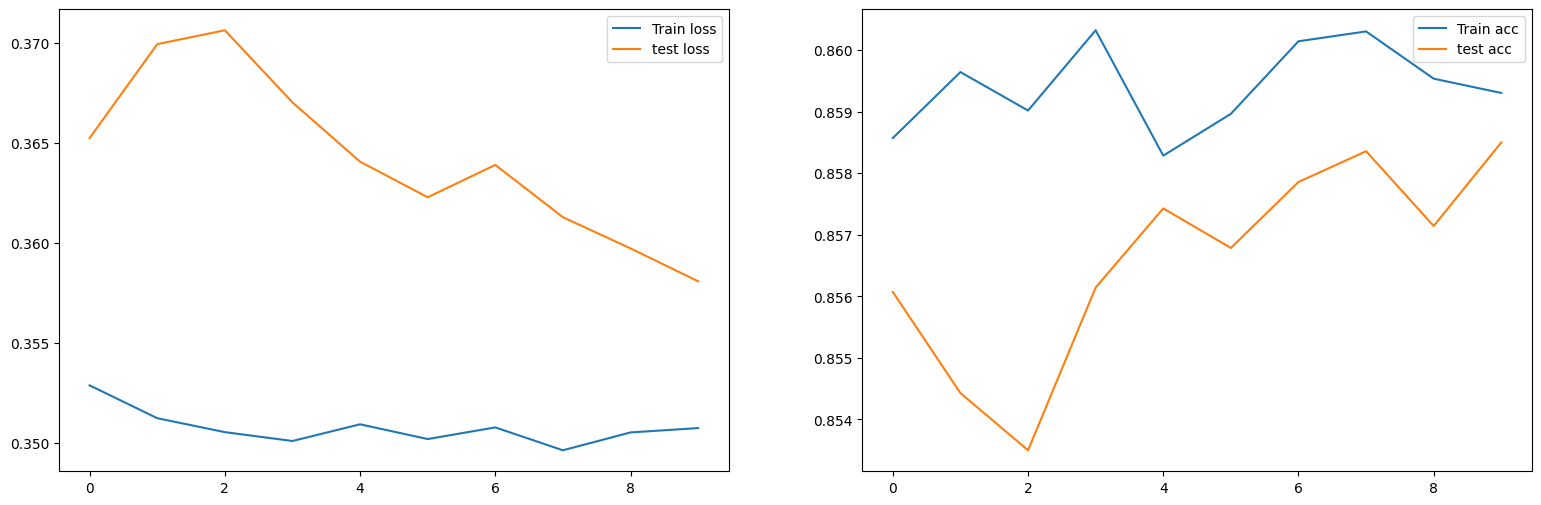

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(19,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='test loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['binary_accuracy'],label='Train acc')
plt.plot(history.history['val_binary_accuracy'],label='test acc')
plt.legend()

In [42]:
test_loss, test_acc, test_auc = model.evaluate(test_gen)

print(f"Test Loss: {test_loss:.4f}")
print(f"Binary Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 924ms/step - auc: 0.7762 - binary_accuracy: 0.8123 - loss: 0.4705
Test Loss: 0.4705
Binary Accuracy: 0.8123
Test AUC: 0.7762


In [43]:
images, labels = next(test_gen)

preds = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


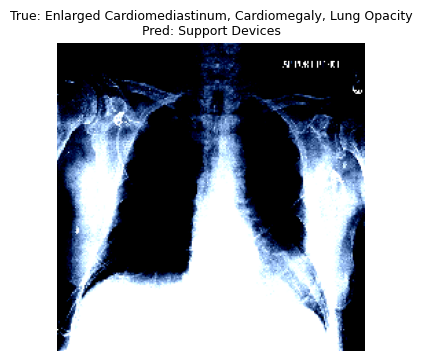

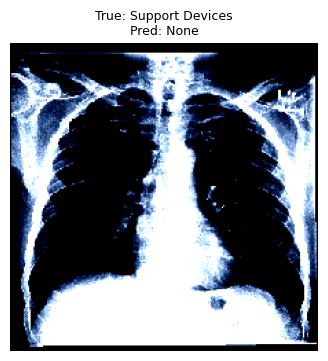

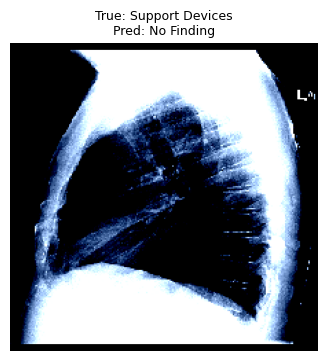

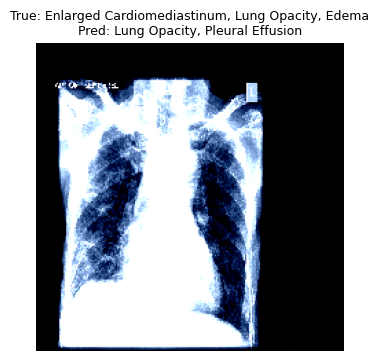

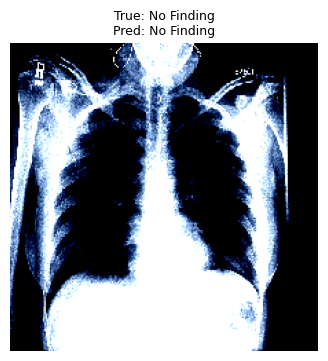

In [44]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(5):

    plt.figure(figsize=(4,4))
    plt.imshow(images[i])
    plt.axis("off")

    # الأمراض الحقيقية
    true_labels = np.where(labels[i] == 1)[0]

    # الأمراض المتوقعة (Threshold = 0.5)
    pred_labels = np.where(preds[i] >= 0.5)[0]

    true_names = [disease_cols[j] for j in true_labels]
    pred_names = [disease_cols[j] for j in pred_labels]

    plt.title(
        f"True: {', '.join(true_names) if true_names else 'None'}\n"
        f"Pred: {', '.join(pred_names) if pred_names else 'None'}",
        fontsize=9
    )

    plt.show()